# Análise exploratória de pedidos | Maria de Fátima: 2024013296 & Rayssa Simões: 2024009702

Este notebook usa somente `pedidos_sinteticos.csv` e `DICIONARIO.md`.
O CSV bruto deve permanecer preservado; a análise usará uma cópia lógica.

## Pergunta escolhida

Escolha uma pergunta do roteiro de `laboratorio.md` e registre aqui a expectativa inicial.

 Pergunta escolhida: como entrega e satisfação se relacionam nos pedidos com informação completa?
 **Expectativa inicial**: esperamos observar uma associação negativa entre mais dias de entrega e menor satisfação, mas a análise não permitirá concluir causalidade.

In [6]:
# Preparação: executar antes das demais células.
from pathlib import Path
import pandas as pd

ARQUIVO = Path('pedidos_sinteticos.csv')
raw = pd.read_csv(ARQUIVO, encoding='utf-8-sig')
raw_original = raw.copy(deep=True)
raw.head()

,pedido_id,data,canal,categoria,valor_brl,entrega_dias,satisfacao
0,P001,2026-04-01,Orgânico,Livros,70,NaN,4.2
1,P002,2026-04-01,Pago,Casa,177,9.0,1.9
2,P003,2026-04-02,Orgânico,Tecnologia,104,8.0,1.9
3,P004,2026-04-02,Pago,Livros,211,7.0,3.0
4,P005,2026-04-03,Orgânico,Casa,138,6.0,3.0


## 1. Auditoria da qualidade dos dados

Verificar dimensões, tipos, intervalo de datas, ausentes por coluna, duplicatas exatas, IDs repetidos e conflitos, além dos valores incompatíveis com o dicionário. Contar ausentes antes de cada cálculo.

In [7]:
# Auditoria do arquivo bruto; nenhuma alteração é feita em raw.
print("Dimensões:", raw.shape)
print("Colunas:", raw.columns.tolist())
print("Tipos:")
display(raw.dtypes.to_frame("tipo"))

data_convertida = pd.to_datetime(raw["data"], format="%Y-%m-%d", errors="coerce")
print("Intervalo de datas:", data_convertida.min(), "a", data_convertida.max())
print("Datas inválidas:", int(data_convertida.isna().sum()))

print("Ausentes por coluna:")
display(raw.isna().sum().to_frame("quantidade"))

duplicatas_exatas = raw[raw.duplicated(keep=False)].sort_values(raw.columns.tolist())
print("Linhas em duplicatas exatas:", len(duplicatas_exatas))
display(duplicatas_exatas)

contagem_ids = raw["pedido_id"].value_counts()
ids_repetidos = contagem_ids[contagem_ids > 1]
print("IDs repetidos:")
display(ids_repetidos.to_frame("quantidade"))

for pedido_id in ids_repetidos.index:
	grupo = raw[raw["pedido_id"] == pedido_id]
	tipo = "duplicata exata" if grupo.drop_duplicates().shape[0] == 1 else "conflitante"
	print(f"{pedido_id}: {tipo}; registros distintos = {grupo.drop_duplicates().shape[0]}")
	display(grupo)

auditoria = raw.copy()
for coluna in ["valor_brl", "entrega_dias", "satisfacao"]:
	auditoria[coluna] = pd.to_numeric(auditoria[coluna], errors="coerce")

problemas = {
	"valor_brl não positivo": auditoria["valor_brl"].notna() & (auditoria["valor_brl"] <= 0),
	"entrega_dias negativa": auditoria["entrega_dias"].notna() & (auditoria["entrega_dias"] < 0),
	"satisfacao fora de 1 a 5": auditoria["satisfacao"].notna() & ~auditoria["satisfacao"].between(1, 5),
	"canal fora do domínio": ~raw["canal"].isin(["Pago", "Orgânico"]),
	"categoria fora do domínio": ~raw["categoria"].isin(["Livros", "Casa", "Tecnologia"]),
}

print("Problemas incompatíveis com o dicionário:")
for nome, mascara in problemas.items():
	print(f"- {nome}: {int(mascara.sum())}")
	if mascara.any():
		display(raw.loc[mascara])

Dimensões: (62, 7)
Colunas: ['pedido_id', 'data', 'canal', 'categoria', 'valor_brl', 'entrega_dias', 'satisfacao']
Tipos:


,tipo
pedido_id,str
data,str
canal,str
categoria,str
valor_brl,int64
entrega_dias,float64
satisfacao,float64


Intervalo de datas: 2026-04-01 00:00:00 a 2026-04-30 00:00:00
Datas inválidas: 0
Ausentes por coluna:


,quantidade
pedido_id,0
data,0
canal,0
categoria,0
valor_brl,0
entrega_dias,6
satisfacao,0


Linhas em duplicatas exatas: 2


...

P012: duplicata exata; registros distintos = 1


,pedido_id,data,canal,categoria,valor_brl,entrega_dias,satisfacao
11,P012,2026-04-06,Pago,Tecnologia,167,7.0,2.8
61,P012,2026-04-06,Pago,Tecnologia,167,7.0,2.8


Problemas incompatíveis com o dicionário:
- valor_brl não positivo: 1


,pedido_id,data,canal,categoria,valor_brl,entrega_dias,satisfacao
60,P061,2026-04-30,Pago,Casa,-40,4.0,4.0


- entrega_dias negativa: 0
- satisfacao fora de 1 a 5: 0
- canal fora do domínio: 0
- categoria fora do domínio: 0


## 2. Base de trabalho e registro de alterações

Remover somente a ocorrência excedente da duplicata exata e separar o pedido incompatível com `valor_brl > 0`. Não imputar ausentes e não remover automaticamente o valor alto. Registrar linhas antes e depois de cada etapa.

In [8]:
# Base lógica: não sobrescrever raw nem o arquivo CSV.
base_trabalho = raw.copy(deep=True)
registro_alteracoes = [{
	"etapa": "bruta",
	"alteracao": "nenhuma; cópia lógica criada",
	"linhas_antes": len(base_trabalho),
	"linhas_depois": len(base_trabalho),
	"linhas_removidas": 0,
}]

# Remove somente as ocorrências excedentes de linhas inteiramente duplicadas.
duplicata_exata = base_trabalho.duplicated(keep="first")
base_sem_duplicatas = base_trabalho.loc[~duplicata_exata].copy()
registro_alteracoes.append({
	"etapa": "duplicatas exatas",
	"alteracao": "removida a ocorrência excedente de P012",
	"linhas_antes": len(base_trabalho),
	"linhas_depois": len(base_sem_duplicatas),
	"linhas_removidas": int(duplicata_exata.sum()),
})

# Separa valores incompatíveis com o contrato, sem alterar o CSV bruto.
valor_numerico = pd.to_numeric(base_sem_duplicatas["valor_brl"], errors="coerce")
mascara_invalido = valor_numerico.isna() | (valor_numerico <= 0)
pedidos_invalidos = base_sem_duplicatas.loc[mascara_invalido].copy()
base_trabalho = base_sem_duplicatas.loc[~mascara_invalido].copy()
registro_alteracoes.append({
	"etapa": "valores incompatíveis",
	"alteracao": "P061 separado por valor_brl <= 0",
	"linhas_antes": len(base_sem_duplicatas),
	"linhas_depois": len(base_trabalho),
	"linhas_removidas": int(mascara_invalido.sum()),
})

registro_alteracoes = pd.DataFrame(registro_alteracoes)
print("Registro de alterações:")
display(registro_alteracoes)
print("Pedidos separados como inválidos:")
display(pedidos_invalidos)
print("Linhas na base de trabalho:", len(base_trabalho))
print("Ausentes em entrega_dias:", int(base_trabalho["entrega_dias"].isna().sum()))
print("P048 preservado:", bool((base_trabalho["pedido_id"] == "P048").any()))

assert len(raw) == 62
assert len(base_sem_duplicatas) == 61
assert len(base_trabalho) == 60
assert set(pedidos_invalidos["pedido_id"]) == {"P061"}
assert (raw.equals(raw_original))

Registro de alterações:


,etapa,alteracao,linhas_antes,linhas_depois,linhas_removidas
0,bruta,nenhuma; cópia lógica criada,62,62,0
1,duplicatas exatas,removida a ocorrência excedente de P012,62,61,1
2,valores incompatíveis,P061 separado por valor_brl <= 0,61,60,1


Pedidos separados como inválidos:


,pedido_id,data,canal,categoria,valor_brl,entrega_dias,satisfacao
60,P061,2026-04-30,Pago,Casa,-40,4.0,4.0


Linhas na base de trabalho: 60
Ausentes em entrega_dias: 6
P048 preservado: True


## 3. Resumos e gráficos

Calcular contagens por canal e `valor_brl`: n, média, mediana, desvio-padrão amostral (`ddof=1`), Q1, Q3 e IQR, com quartis por interpolação linear. Criar dois gráficos com eixos, unidades, n e fonte.

In [9]:
# Resumos numéricos da base de trabalho.
base_resumo = base_trabalho.copy()
base_resumo["valor_brl_num"] = pd.to_numeric(base_resumo["valor_brl"], errors="coerce")

valor = base_resumo["valor_brl_num"]
valor_valido = valor.dropna()
quartis = valor_valido.quantile([0.25, 0.75], interpolation="linear")
modas = valor_valido.mode().tolist()

resumo_valor = pd.DataFrame({
	"n_valido": [valor_valido.count()],
	"ausentes": [valor.isna().sum()],
	"media_brl": [valor_valido.mean()],
	"mediana_brl": [valor_valido.median()],
	"modas_brl": [modas],
	"minimo_brl": [valor_valido.min()],
	"maximo_brl": [valor_valido.max()],
	"amplitude_brl": [valor_valido.max() - valor_valido.min()],
	"variancia_amostral_brl2": [valor_valido.var(ddof=1)],
	"desvio_padrao_amostral_brl": [valor_valido.std(ddof=1)],
	"Q1_brl": [quartis.loc[0.25]],
	"Q3_brl": [quartis.loc[0.75]],
	"IQR_brl": [quartis.loc[0.75] - quartis.loc[0.25]],
})

print("Resumo de valor_brl; quartis por interpolação linear e ddof=1:")
display(resumo_valor)

denominador = len(base_trabalho)
contagens_canal = base_trabalho["canal"].value_counts(dropna=False).rename("n").to_frame()
contagens_canal["percentual"] = 100 * contagens_canal["n"] / denominador
print(f"Contagens por canal; denominador = {denominador} pedidos:")
display(contagens_canal)

contagens_categoria = base_trabalho["categoria"].value_counts(dropna=False).rename("n").to_frame()
contagens_categoria["percentual"] = 100 * contagens_categoria["n"] / denominador
print(f"Contagens por categoria; denominador = {denominador} pedidos:")
display(contagens_categoria)

por_canal = (
	base_resumo.groupby("canal", dropna=False)["valor_brl_num"]
	.agg(n="count", media_brl="mean", mediana_brl="median")
	.reset_index()
)
print("Valor por canal; n considera somente valor_brl válido:")
display(por_canal)

ausentes_entrega = int(base_trabalho["entrega_dias"].isna().sum())
print(f"entrega_dias ausente: {ausentes_entrega} de {len(base_trabalho)}; ausentes não foram substituídos por zero.")

print("Observações descritivas:")
print(f"1. A base de trabalho tem {len(base_trabalho)} pedidos e {ausentes_entrega} entregas sem informação.")
print(f"2. O valor observado varia de R$ {valor_valido.min():.2f} a R$ {valor_valido.max():.2f}; P048 foi mantido.")
canal_maior_mediana = por_canal.loc[por_canal["mediana_brl"].idxmax(), "canal"]
print(f"3. O canal com maior mediana de valor_brl é {canal_maior_mediana}; isso é uma descrição, não evidência causal.")

print("Hipótese: pedidos com mais dias de entrega tendem a apresentar menor satisfação.")
print("Limitação: uma associação observada não prova causalidade, e a base é sintética e pequena.")

Resumo de valor_brl; quartis por interpolação linear e ddof=1:


,n_valido,ausentes,media_brl,mediana_brl,modas_brl,minimo_brl,maximo_brl,amplitude_brl,variancia_amostral_brl2,desvio_padrao_amostral_brl,Q1_brl,Q3_brl,IQR_brl
0,60,0,195.016667,158.5,"[70, 72, 74, 76, 82, 84, 86, 88, 94, 96, 98, 1...",70,2400,2330,86553.203107,294.199257,114.5,203.5,89.0


Contagens por canal; denominador = 60 pedidos:


,n,percentual
canal,,
Orgânico,30,50.0
Pago,30,50.0


Contagens por categoria; denominador = 60 pedidos:


,n,percentual
categoria,,
Livros,20,33.333333
Casa,20,33.333333
Tecnologia,20,33.333333


Valor por canal; n considera somente valor_brl válido:


,canal,n,media_brl,mediana_brl
0,Orgânico,30,113.000000,113.0
1,Pago,30,277.033333,204.0


entrega_dias ausente: 6 de 60; ausentes não foram substituídos por zero.
Observações descritivas:
1. A base de trabalho tem 60 pedidos e 6 entregas sem informação.
2. O valor observado varia de R$ 70.00 a R$ 2400.00; P048 foi mantido.
3. O canal com maior mediana de valor_brl é Pago; isso é uma descrição, não evidência causal.
Hipótese: pedidos com mais dias de entrega tendem a apresentar menor satisfação.
Limitação: uma associação observada não prova causalidade, e a base é sintética e pequena.


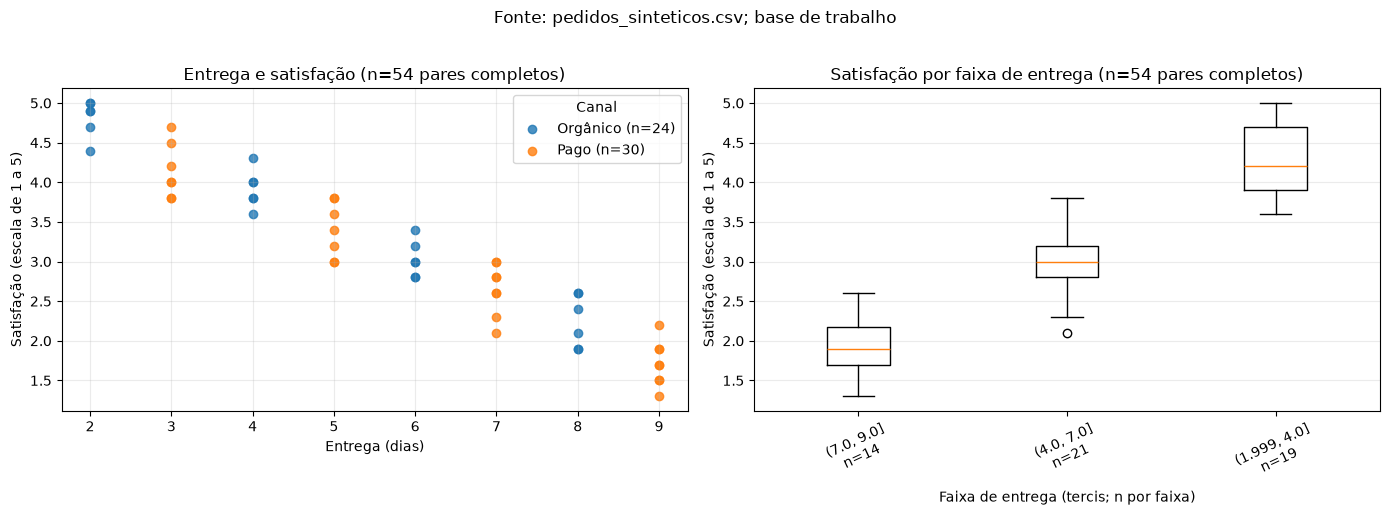

In [10]:
# Dois gráficos para a relação entre entrega e satisfação.
import matplotlib.pyplot as plt

pares_completos = base_trabalho.dropna(subset=["entrega_dias", "satisfacao"]).copy()
n_pares = len(pares_completos)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

for canal, grupo in pares_completos.groupby("canal", dropna=False):
	eixos[0].scatter(
		grupo["entrega_dias"],
		grupo["satisfacao"],
		label=f"{canal} (n={len(grupo)})",
		alpha=0.8,
	)
eixos[0].set_title(f"Entrega e satisfação (n={n_pares} pares completos)")
eixos[0].set_xlabel("Entrega (dias)")
eixos[0].set_ylabel("Satisfação (escala de 1 a 5)")
eixos[0].legend(title="Canal")
eixos[0].grid(alpha=0.25)

pares_completos["faixa_entrega"] = pd.qcut(
	pares_completos["entrega_dias"],
	q=3,
	duplicates="drop",
)
faixas = pares_completos["faixa_entrega"].dropna().unique().tolist()
dados_boxplot = [
	pares_completos.loc[pares_completos["faixa_entrega"] == faixa, "satisfacao"]
	for faixa in faixas
]
contagens_faixas = [len(dados) for dados in dados_boxplot]
rótulos_faixas = [
	f"{faixa}\nn={n}"
	for faixa, n in zip(faixas, contagens_faixas)
]
eixos[1].boxplot(dados_boxplot, tick_labels=rótulos_faixas)
eixos[1].set_title(f"Satisfação por faixa de entrega (n={n_pares} pares completos)")
eixos[1].set_xlabel("Faixa de entrega (tercis; n por faixa)")
eixos[1].set_ylabel("Satisfação (escala de 1 a 5)")
eixos[1].tick_params(axis="x", rotation=25)
eixos[1].grid(axis="y", alpha=0.25)

fig.suptitle("Fonte: pedidos_sinteticos.csv; base de trabalho", y=1.02)
fig.tight_layout()
plt.show()

## 4. Investigação e interpretação

Investigar P048 ou a relação entre entrega e satisfação. Declarar pares completos quando aplicável, comparar cenários sem apagar a base principal e não transformar associação em causalidade.

In [11]:
# Relação entre entrega e satisfação usando somente pares completos.
analise_relacao = base_trabalho[["entrega_dias", "satisfacao"]].copy()
analise_relacao["entrega_dias"] = pd.to_numeric(analise_relacao["entrega_dias"], errors="coerce")
analise_relacao["satisfacao"] = pd.to_numeric(analise_relacao["satisfacao"], errors="coerce")

ausentes_entrega_relacao = int(analise_relacao["entrega_dias"].isna().sum())
ausentes_satisfacao_relacao = int(analise_relacao["satisfacao"].isna().sum())
pares_completos_relacao = analise_relacao.dropna(subset=["entrega_dias", "satisfacao"]).copy()
n_pares_completos = len(pares_completos_relacao)

pearson = pares_completos_relacao["entrega_dias"].corr(
    pares_completos_relacao["satisfacao"], method="pearson"
)
spearman = pares_completos_relacao["entrega_dias"].rank().corr(
    pares_completos_relacao["satisfacao"].rank(), method="pearson"
)

resumo_correlacao = pd.DataFrame({
    "medida": ["Pearson", "Spearman"],
    "n_pares_completos": [n_pares_completos, n_pares_completos],
    "coeficiente": [pearson, spearman],
})

print(f"Ausentes antes da correlação: entrega_dias={ausentes_entrega_relacao}; satisfacao={ausentes_satisfacao_relacao}.")
print(f"Pares completos usados: {n_pares_completos} de {len(analise_relacao)} pedidos.")
display(resumo_correlacao)

sentido = "negativa" if pearson < 0 else "positiva" if pearson > 0 else "nula"
print(f"Observação: a associação linear de Pearson é {sentido} (r={pearson:.4f}); Spearman={spearman:.4f}.")
print("Interpretação: os coeficientes descrevem associação nos pares completos e não demonstram que o prazo causou a satisfação.")
print("Hipótese: fatores não observados, como expectativa do cliente ou categoria do pedido, podem contribuir para o padrão.")
print("Limitação: a amostra é sintética, há dados ausentes e correlação não permite inferência causal.")

Ausentes antes da correlação: entrega_dias=6; satisfacao=0.
Pares completos usados: 54 de 60 pedidos.


,medida,n_pares_completos,coeficiente
0,Pearson,54,-0.959186
1,Spearman,54,-0.963448


Observação: a associação linear de Pearson é negativa (r=-0.9592); Spearman=-0.9634.
Interpretação: os coeficientes descrevem associação nos pares completos e não demonstram que o prazo causou a satisfação.
Hipótese: fatores não observados, como expectativa do cliente ou categoria do pedido, podem contribuir para o padrão.
Limitação: a amostra é sintética, há dados ausentes e correlação não permite inferência causal.


In [12]:
# Sensibilidade ao pedido extremo, sem remover P048 da base principal.
valores_iqr = base_trabalho.assign(
	valor_brl_num=pd.to_numeric(base_trabalho["valor_brl"], errors="coerce")
)
q1_iqr, q3_iqr = valores_iqr["valor_brl_num"].quantile(
	[0.25, 0.75], interpolation="linear"
)
iqr = q3_iqr - q1_iqr
limite_inferior = q1_iqr - 1.5 * iqr
limite_superior = q3_iqr + 1.5 * iqr
mascara_outlier = (
	valores_iqr["valor_brl_num"] < limite_inferior
) | (valores_iqr["valor_brl_num"] > limite_superior)
ids_outliers = valores_iqr.loc[mascara_outlier, "pedido_id"].tolist()

cenarios_valor = pd.DataFrame({
	"cenário": ["com P048", "sem P048 (exploratório)"],
	"n": [valores_iqr["valor_brl_num"].count(), (~mascara_outlier).sum()],
	"média_brl": [
		valores_iqr["valor_brl_num"].mean(),
		valores_iqr.loc[~mascara_outlier, "valor_brl_num"].mean(),
	],
	"mediana_brl": [
		valores_iqr["valor_brl_num"].median(),
		valores_iqr.loc[~mascara_outlier, "valor_brl_num"].median(),
	],
	"desvio_padrao_amostral_brl": [
		valores_iqr["valor_brl_num"].std(ddof=1),
		valores_iqr.loc[~mascara_outlier, "valor_brl_num"].std(ddof=1),
	],
})

print(f"Q1={q1_iqr:.1f}; Q3={q3_iqr:.1f}; IQR={iqr:.1f}.")
print(f"Limites de 1,5 IQR: {limite_inferior:.1f} a {limite_superior:.1f}.")
print(f"IDs sinalizados: {ids_outliers}; ausentes em valor_brl antes do cálculo: {int(valores_iqr['valor_brl_num'].isna().sum())}.")
display(cenarios_valor)
print(f"Base principal preservada: {len(base_trabalho)} pedidos; P048 presente: {bool((base_trabalho['pedido_id'] == 'P048').any())}.")

Q1=114.5; Q3=203.5; IQR=89.0.
Limites de 1,5 IQR: -19.0 a 337.0.
IDs sinalizados: ['P048']; ausentes em valor_brl antes do cálculo: 0.


,cenário,n,média_brl,mediana_brl,desvio_padrao_amostral_brl
0,com P048,60,195.016667,158.5,294.199257
1,sem P048 (exploratório),59,157.644068,156.0,52.895721


Base principal preservada: 60 pedidos; P048 presente: True.


In [13]:
# Revisão cruzada: três números conferidos por cálculo independente.
valores_independentes = sorted(
	pd.to_numeric(base_trabalho["valor_brl"], errors="coerce").dropna().tolist()
)
n_independente = len(valores_independentes)
media_independente = sum(valores_independentes) / n_independente
mediana_independente = (
	valores_independentes[n_independente // 2 - 1]
	+ valores_independentes[n_independente // 2]
) / 2
posição_q1 = (n_independente - 1) * 0.25
baixo_q1 = int(posição_q1)
alto_q1 = baixo_q1 + 1
q1_independente = valores_independentes[baixo_q1] + (
	valores_independentes[alto_q1] - valores_independentes[baixo_q1]
) * (posição_q1 - baixo_q1)

print(f"Média independente = soma/n = {sum(valores_independentes):.1f}/{n_independente} = {media_independente:.4f}.")
print(f"Mediana independente = média das posições 30 e 31 = {mediana_independente:.1f}.")
print(f"Q1 independente = interpolação linear na posição {posição_q1:.2f} = {q1_independente:.1f}.")
print("Contagem independente por canal:")
display(base_trabalho["canal"].value_counts(dropna=False).rename("n").to_frame())

Média independente = soma/n = 11701.0/60 = 195.0167.
Mediana independente = média das posições 30 e 31 = 158.5.
Q1 independente = interpolação linear na posição 14.75 = 114.5.
Contagem independente por canal:


,n
canal,
Orgânico,30
Pago,30


## 5. Revisão cruzada e relato final

Conferir independentemente pelo menos três números. Registrar: **Observamos**, **Uma hipótese**, **Precisamos verificar** e **Limitação**. Guardar neste notebook o código efetivamente executado e suas saídas.

## Relato final

**Observamos:** na base de trabalho, há 60 pedidos, 6 entregas ausentes e 54 pares completos para a relação entre entrega e satisfação. A associação observada é negativa (Pearson = -0,9592; Spearman = -0,9634), e os gráficos mostram esse padrão nos dados disponíveis. No valor dos pedidos, a média é R$ 195,0167 e a mediana é R$ 158,50. O IQR sinaliza somente P048; com o pedido incluído, o desvio-padrão amostral é R$ 294,1993; sem ele, em cenário exploratório, é R$ 52,8957.

**Uma hipótese:** expectativas do cliente, categoria do pedido ou outros fatores não observados podem contribuir para a relação entre prazo e satisfação. Essa explicação não foi demonstrada pelos dados atuais.

**Precisamos verificar:** comprovante, quantidade e contexto do pedido P048; também seria necessário investigar fatores de confusão e a origem dos dados de satisfação antes de interpretar a associação além desta base sintética.

**Limitação:** os dados são sintéticos, pequenos e têm 6 entregas ausentes. A análise é descritiva; associação não demonstra causalidade, e o cenário sem P048 é apenas uma análise de sensibilidade, não uma nova base definitiva.